## Pertanyaan Bisnis

- ***Pertanyaan 1***

    Seberapa besar Fraud Rate di Negara Tujuan TKW?
- ***Pertanyaan 2***

    Berapa rata-rata perbedaan gaji antara Salary Fraud vs Legitimate? Apakah lowongan palsu menawarkan gaji lebih tinggi?
- ***Pertanyaan 3***

    Fitur apa yang paling berpengaruh dalam mendeteksi lowongan palsu?
- ***Pertanyaan 4***

    Pola pekerjaan & tipe employment yang sering menjadi target lowongan palsu?
- ***Pertanyaan 5***

    Performa model setelah tuning vs baseline?

## Import Packages/Library

In [3]:
# Import library yang dibutuhkan
import os, re, warnings
import json as _json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold, cross_val_score
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import (classification_report, confusion_matrix, accuracy_score,
    f1_score, roc_auc_score, roc_curve, mean_absolute_error, mean_squared_error, r2_score)
from xgboost import XGBClassifier, XGBRegressor
import shap
import category_encoders as ce
import joblib
from IPython.display import clear_output
from pycaret.classification import (setup as pc_setup, compare_models,
                                    pull as pc_pull, finalize_model,
                                    predict_model, plot_model)

# Konfigurasi
warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('husl')
plt.rcParams.update({'figure.figsize': (12, 6), 'font.size': 12})
DATA_DIR = os.path.join(os.getcwd(), 'data')

## Data Wrangling

### Gathering Data

In [4]:
# Membaca dataset
df1 = pd.read_csv(os.path.join(DATA_DIR, 'fake_job_postings.csv'))

# Menampilkan 5 baris pertama
df1.head()

,job_id,title,location,department,salary_range,company_profile,description,requirements,benefits,telecommuting,has_company_logo,has_questions,employment_type,required_experience,required_education,industry,function,fraudulent
0,1,Marketing Intern,"US, NY, New York",Marketing,NaN,"We're Food52, and we've created a groundbreaki...","Food52, a fast-growing, James Beard Award-winn...",Experience with content management systems a m...,NaN,0,1,0,Other,Internship,NaN,NaN,Marketing,0
1,2,Customer Service - Cloud Video Production,"NZ, , Auckland",Success,NaN,"90 Seconds, the worlds Cloud Video Production ...",Organised - Focused - Vibrant - Awesome!Do you...,What we expect from you:Your key responsibilit...,What you will get from usThrough being part of...,0,1,0,Full-time,Not Applicable,NaN,Marketing and Advertising,Customer Service,0
2,3,Commissioning Machinery Assistant (CMA),"US, IA, Wever",NaN,NaN,Valor Services provides Workforce Solutions th...,"Our client, located in Houston, is actively se...",Implement pre-commissioning and commissioning ...,NaN,0,1,0,NaN,NaN,NaN,NaN,NaN,0
3,4,Account Executive - Washington DC,"US, DC, Washington",Sales,NaN,Our passion for improving quality of life thro...,THE COMPANY: ESRI – Environmental Systems Rese...,"EDUCATION: Bachelor’s or Master’s in GIS, busi...",Our culture is anything but corporate—we have ...,0,1,0,Full-time,Mid-Senior level,Bachelor's Degree,Computer Software,Sales,0
4,5,Bill Review Manager,"US, FL, Fort Worth",NaN,NaN,SpotSource Solutions LLC is a Global Human Cap...,JOB TITLE: Itemization Review ManagerLOCATION:...,QUALIFICATIONS:RN license in the State of Texa...,Full Benefits Offered,0,1,1,Full-time,Mid-Senior level,Bachelor's Degree,Hospital & Health Care,Health Care Provider,0


In [5]:
# Total semua dataset
print(f"Dataset 1: {df1.shape[0]} baris, {df1.shape[1]} kolom")

Dataset 1: 17880 baris, 18 kolom


**Insight**
- Datasetnya lumayan besar dengan total 17.880 baris dan 18 kolom. Kolom fradulent di bagian paling kanan bakal jadi target utama kita kita buat memprediksi mana loker yang asli atau palsu.
- Dari 5 baris pertama saja sudah kelihatan banyak nilai NoN, contohnya di kolom salary_range, department, dan benefits. Ini artinya kita butuh proses data cleaning untuk beresin nilai yang hilang ini nanti.
- Sebagian besar isi datanya berupa teks panjang (seperti company_profile, description, requirements). Karena model Machine Learning cuma bisa baca angka, nanti kita harus ubah teks-teks ini jadi format angka (pakai teknik NLP).

## Assessing Data

In [6]:
# Melakukan pengecekan Missing Value
print(f"Shape: {df1.shape} | Duplikasi: {df1.duplicated().sum()}")
missing = df1.isnull().sum()
missing_pct = (missing / len(df1) * 100).round(2)
mv = pd.DataFrame({'Jumlah': missing, 'Persen(%)': missing_pct})
print(mv[mv['Jumlah'] > 0].to_string() if mv[mv['Jumlah'] > 0].shape[0] > 0
      else "  Tidak ada missing values")
print(f"\nDataset: {df1['fraudulent'].value_counts().to_dict()}")

Shape: (17880, 18) | Duplikasi: 0
                     Jumlah  Persen(%)
location                346       1.94
department            11547      64.58
salary_range          15012      83.96
company_profile        3308      18.50
description               1       0.01
requirements           2696      15.08
benefits               7212      40.34
employment_type        3471      19.41
required_experience    7050      39.43
required_education     8105      45.33
industry               4903      27.42
function               6455      36.10

Dataset: {0: 17014, 1: 866}


**Insight**
- Dari total 17.880 baris data, tidak ada satu pun baris yang ganda atau duplikat (Duplikasi: 0). Semua datanya unik.
- Tabel menunjukkan banyak data yang kosong. Kolom salary_range jadi yang paling parah karena hampir 84% datanya tidak ada, diusul department (64%). Karena persentase hilangnya sangat besar, kita perlu pertimbangkan apakah kolom-kolom ini layak dipertahankan atau lebih baik didrop saja.
- Proporsi target klasifikasinya berat sebelah. Loker yang asli (0) jumlahnya 17.014, sedangkan yang palsu (1) cuma 866. Ketimpangan ekstrem ini harus ditangani nantinya misalnya pakai teknik oversampling seperti SMOTE, agar model tidak bias dan selalu menebak loker asli.

## Cleaning Data

In [7]:
# Cek Perubahan
df1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17880 entries, 0 to 17879
Data columns (total 18 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   job_id               17880 non-null  int64 
 1   title                17880 non-null  object
 2   location             17534 non-null  object
 3   department           6333 non-null   object
 4   salary_range         2868 non-null   object
 5   company_profile      14572 non-null  object
 6   description          17879 non-null  object
 7   requirements         15184 non-null  object
 8   benefits             10668 non-null  object
 9   telecommuting        17880 non-null  int64 
 10  has_company_logo     17880 non-null  int64 
 11  has_questions        17880 non-null  int64 
 12  employment_type      14409 non-null  object
 13  required_experience  10830 non-null  object
 14  required_education   9775 non-null   object
 15  industry             12977 non-null  object
 16  func

In [8]:
def parse_salary(s):
    if pd.isna(s):
        return np.nan, np.nan
    s = str(s).strip()
    if s.lower() in ['not disclosed', '', 'nan']:
        return np.nan, np.nan
    s = s.replace('$', '').replace(',', '')
    if 'k' in s.lower():
        parts = re.findall(r'([\d.]+)\s*k', s, re.IGNORECASE)
        if len(parts) >= 2:
            return float(parts[0]) * 1000, float(parts[1]) * 1000
    parts = re.findall(r'[\d.]+', s)
    if len(parts) >= 2:
        mn, mx = float(parts[0]), float(parts[1])
        if mn < 500 and mx < 500: 
            mn, mx = mn * 2080, mx * 2080
        return mn, mx
    return np.nan, np.nan

COUNTRY_MAP = {
    'US': 'United States', 'GB': 'United Kingdom', 'UK': 'United Kingdom',
    'DE': 'Germany', 'CA': 'Canada', 'AU': 'Australia', 'IN': 'India',
    'NZ': 'New Zealand', 'SG': 'Singapore', 'MY': 'Malaysia',
    'HK': 'Hong Kong', 'AE': 'UAE', 'SA': 'Saudi Arabia', 'JP': 'Japan',
    'KR': 'South Korea', 'TW': 'Taiwan', 'FR': 'France', 'IE': 'Ireland',
    'NL': 'Netherlands', 'CH': 'Switzerland', 'IT': 'Italy', 'ES': 'Spain',
    'SE': 'Sweden', 'PL': 'Poland', 'IL': 'Israel', 'PH': 'Philippines',
    'TH': 'Thailand', 'ID': 'Indonesia', 'BR': 'Brazil', 'ZA': 'South Africa',
    'NG': 'Nigeria', 'QA': 'Qatar', 'KW': 'Kuwait', 'BH': 'Bahrain',
    'JO': 'Jordan', 'CN': 'China', 'BN': 'Brunei', 'TR': 'Turkey',
    'RU': 'Russia', 'RO': 'Romania', 'GR': 'Greece', 'BE': 'Belgium',
    'AT': 'Austria', 'NO': 'Norway', 'DK': 'Denmark', 'FI': 'Finland',
    'PK': 'Pakistan', 'BD': 'Bangladesh', 'EG': 'Egypt', 'OM': 'Oman',
    'LB': 'Lebanon', 'MX': 'Mexico', 'AR': 'Argentina', 'CO': 'Colombia',
    'CL': 'Chile', 'HR': 'Croatia', 'HU': 'Hungary', 'CZ': 'Czech Republic',
    'PT': 'Portugal', 'UA': 'Ukraine', 'RS': 'Serbia', 'BG': 'Bulgaria',
    'LK': 'Sri Lanka', 'MM': 'Myanmar', 'VN': 'Vietnam',
}

def get_country(loc):
    if pd.isna(loc):
        return 'Unknown'
    loc = str(loc).strip()
    code = loc.split(',')[0].strip()
    return COUNTRY_MAP.get(code, code)

# Cleaning Dataset
df = df1[['title', 'location', 'salary_range', 'description', 'requirements',
          'company_profile', 'employment_type', 'industry', 'benefits',
          'telecommuting', 'has_company_logo', 'has_questions', 'fraudulent',
          'required_experience', 'required_education']].copy()

df['country'] = df['location'].apply(get_country)
p = df['salary_range'].apply(parse_salary)
df['salary_min'] = p.apply(lambda x: x[0])
df['salary_max'] = p.apply(lambda x: x[1])

# Handle missing values
for col in ['description', 'requirements', 'company_profile', 'benefits']:
    df[col] = df[col].fillna('')
for col in ['employment_type', 'industry', 'title']:
    df[col] = df[col].fillna('Unknown')

for col in ['required_experience', 'required_education']:
    df[col] = df[col].fillna('Not Specified')

for col in ['telecommuting', 'has_company_logo', 'has_questions']:
    df[col] = df[col].fillna(0).astype(int)

before = len(df)
df.drop_duplicates(subset=['title', 'description', 'location'], keep='first', inplace=True)
df.reset_index(drop=True, inplace=True)
print(f"Duplikat dihapus: {before - len(df)} | Final: {df.shape}")
print(f"Label distribusi: {df['fraudulent'].value_counts().to_dict()}")

Duplikat dihapus: 512 | Final: (17368, 18)
Label distribusi: {0: 16552, 1: 816}


**Insight**
- Dari data teks yang berantakan, kita berhasil mengekstrak informasi yang lebih berguna. Contohnya, kode negara di kolom location sudah diubah menjadi nama negara lengkap di kolom country pakai COUNTRY_MAP. Terus, kolom salary_range yang tadinya teks (seperti "50k-60k") juga sudah dipecah jadi angka salary_min dan salary_max.
- Kita nggak asal hapus baris yang kosong. Kolom teks panjang (deskripsi, syarat, profil) diisi dengan string kosong (''). Kolom kategori yang kosong diisi dengan label "Unknown" atau "Not Specified". Sedangkan fitur biner (seperti telecommuting dkk) diisi dengan angka 0. Cara ini bikin data tetap utuh tanpa merusak informasi yang ada.
- Meskipun di awal (saat Assesing Data) fungsi duplicated() bilang nggak ada duplikat persis 100%, ternyata saat kita cek pakai kombinasi kolom penting (title, description, location), ada 512 data lowongan yang sama persis. Duplikat ini sudah dihapus, bikin jumlah datanya turun dari 17.880 jadi 17.368 baris. Distribusi loker palsunya (target) juga turun sedikit jadi 816.

## Feature Engineering

In [9]:
# Fitur Gaji
df['salary_mid']    = (df['salary_min'] + df['salary_max']) / 2
df['salary_spread'] = df['salary_max'] - df['salary_min']
df['salary_spread_ratio'] = np.where(
    df['salary_mid'] > 0, df['salary_spread'] / df['salary_mid'], np.nan)

df['has_salary'] = df['salary_min'].notna().astype(int)

# Fitur Teks
df['title_length']        = df['title'].str.len()
df['desc_length']         = df['description'].str.len()
df['req_length']          = df['requirements'].str.len()
df['has_company_profile'] = (df['company_profile'].str.len() > 0).astype(int)

# Scam keyword score - gabungan EN + ID (konteks TKW)
# Kata kunci level TINGGI (skor 3): tanda langsung eksploitasi/penipuan migran
# Kata kunci level SEDANG (skor 2): iming-iming umum
# Kata kunci level RENDAH (skor 1): tekanan untuk segera bertindak
SCAM_KW_HIGH = [
    # Bahasa Indonesia - konteks TKW
    'tanpa potong gaji', 'visa turis', 'visa ziarah', 'visa umroh',
    'kirim paspor', 'bayar di muka', 'biaya administrasi', 'proses cepat',
    'p3mi', 'pjtki', 'tidak dipungut biaya', 'gratis visa',
    'gaji tidak dipotong', 'agen resmi terpercaya',
    # Bahasa Inggris - umum
    'guaranteed income', 'no fee required', 'free visa', 'send passport',
    'upfront payment', 'advance payment',
]
SCAM_KW_MED = [
    # Bahasa Indonesia
    'kerja luar negeri', 'gaji besar', 'penghasilan jutaan',
    'langsung diterima', 'tanpa pengalaman', 'tanpa ijazah',
    'tidak perlu pengalaman',
    # Bahasa Inggris
    'work from home', 'no experience needed', 'no degree required',
    'urgent hiring', 'immediate start', 'earn money fast',
    'make money online', 'high income',
]
SCAM_KW_LOW = [
    # Bahasa Indonesia
    'hubungi sekarang', 'daftar sekarang', 'segera lamar',
    'terbatas', 'kuota terbatas',
    # Bahasa Inggris
    'click here', 'act now', 'contact now', 'apply immediately',
    'limited slots',
]

def calc_scam_score(text):
    if not text or not isinstance(text, str):
        return 0
    text = text.lower()
    score = 0
    score += sum(3 for kw in SCAM_KW_HIGH if kw in text)
    score += sum(2 for kw in SCAM_KW_MED  if kw in text)
    score += sum(1 for kw in SCAM_KW_LOW  if kw in text)
    return score

df['scam_keyword_score'] = df['description'].apply(calc_scam_score)

# [Tim AI #2] Deteksi email gratis (indikator penipuan lokal)
df['has_email_in_desc'] = df['description'].str.contains(
    r'[\w.-]+@[\w.-]+\.\w+', regex=True, na=False).astype(int)
df['is_free_email'] = df['description'].str.contains(
    r'@(gmail|yahoo|hotmail|outlook|ymail|aol|mail\.ru|protonmail)\.\w+',
    regex=True, na=False, case=False).astype(int)

df['exclamation_count'] = df['description'].str.count('!').fillna(0)

# Deteksi bahasa Indonesia dalam deskripsi
ID_WORDS = ['kami', 'kerja', 'gaji', 'lowongan', 'dibutuhkan',
            'segera', 'lamar', 'hubungi', 'pria', 'wanita']
df['is_indonesian_posting'] = df['description'].apply(
    lambda x: int(sum(w in str(x).lower() for w in ID_WORDS) >= 3)
)

print(f"Shape setelah FE dasar: {df.shape}")

Shape setelah FE dasar: (17368, 31)


**Insight**
- Kita memperkaya data dengan membuat belasan kolom baru (dari 18 jadi 31 kolom). Contohnya, dari rentang gaji kita hitung nilai tengah dan selisihnya. Kita juga menghitung jumlah karakter pada judul, deskripsi, dan syarat pekerjaan untuk melihat apakah panjang teks bisa membedakan loker asli dan palsu.
- Kita membuat sistem skor manual untuk mendeteksi kata-kata pancingan yang sering dipakai penipu. Fitur ini sengaja disesuaikan dengan konteks penipuan tenaga kerja migran (TKI/TKW) di Indonesia, dengan melacak kata kunci bahaya seperti "visa ziarah", "tanpa potong gaji", atau agen "pjtki". Makin banyak kata-kata ini muncul, skornya makin tinggi.
- Loker bodong biasanya menyuruh pelamar mengirim berkas ke email gratisan (Gmail/Yahoo) yang diselipkan di dalam deskripsi, serta berlebihan memakai tanda seru (!). Kita bikin fitur khusus untuk melacak keberadaan email ini dan menghitung jumlah tanda serunya, ditambah fitur untuk mendeteksi apakah loker tersebut menggunakan bahasa Indonesia.

## Modeling

In [10]:
# Train-Test Split
X_base = df.drop(columns=['fraudulent'])
y      = df['fraudulent']
X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X_base, y, test_size=0.2, random_state=42, stratify=y
)
print(f"Train: {len(X_train_raw)} | Test: {len(X_test_raw)} | Fraud rate train: {y_train.mean()*100:.1f}%")

# Fungsi create_features (LEAKAGE-FREE)
def create_features(X_data, X_train_ref, y_train_ref):
    X_out = X_data.copy()

    te = ce.TargetEncoder(
        cols=['country', 'employment_type', 'industry'],
        smoothing=1.0       
    )
    te.fit(X_train_ref[['country', 'employment_type', 'industry']], y_train_ref)
    enc_res = te.transform(X_out[['country', 'employment_type', 'industry']])

    X_out['country_fraud_rate']  = enc_res['country']
    X_out['country_safety_score'] = 1 - enc_res['country']  
    X_out['emp_type_fraud_rate'] = enc_res['employment_type']
    X_out['industry_fraud_rate'] = enc_res['industry']

    legit_mask  = (y_train_ref == 0) & X_train_ref['salary_mid'].notna()
    legit_train = X_train_ref[legit_mask]
    cs_avg      = legit_train.groupby('country')['salary_mid'].median().to_dict()
    global_med  = legit_train['salary_mid'].median() if len(legit_train) > 0 else 0

    X_out['country_avg_salary']   = X_out['country'].map(cs_avg).fillna(global_med)
    X_out['salary_vs_country_avg'] = np.where(
        X_out['salary_mid'].notna() & (X_out['country_avg_salary'] > 0),
        X_out['salary_mid'] / X_out['country_avg_salary'],
        np.nan
    )

    salary_cols = ['salary_mid', 'salary_spread', 'salary_spread_ratio',
                   'salary_vs_country_avg']
    X_out[salary_cols]             = X_out[salary_cols].fillna(-1)
    X_out['country_avg_salary']    = X_out['country_avg_salary'].fillna(global_med)

    tfidf = TfidfVectorizer(
        max_features=100,
        stop_words='english',
        sublinear_tf=True,  
        ngram_range=(1, 2)          
    )
    tfidf.fit(X_train_ref['description'])
    tfidf_feat = tfidf.transform(X_out['description']).toarray()
    tfidf_cols = [f'tfidf_{i}' for i in range(100)]
    tfidf_df   = pd.DataFrame(tfidf_feat, columns=tfidf_cols, index=X_out.index)
    X_out      = pd.concat([X_out, tfidf_df], axis=1)

    FEATURES_LIST = [
        # Fitur gaji (sentinel -1 untuk missing)
        'salary_mid', 'salary_spread', 'salary_spread_ratio', 'has_salary',
        # Fitur teks
        'title_length', 'desc_length', 'req_length', 'has_company_profile',
        # Fitur fraud signal
        'scam_keyword_score', 'has_email_in_desc', 'is_free_email',
        'exclamation_count', 'is_indonesian_posting',
        # Fitur kontekstual (dari TargetEncoder)
        'country_fraud_rate', 'country_safety_score', 'country_avg_salary',
        'salary_vs_country_avg',
        # Fitur biner
        'telecommuting', 'has_company_logo', 'has_questions',
        # Fitur target-encoded lainnya
        'emp_type_fraud_rate', 'industry_fraud_rate',
    ] + tfidf_cols

    return X_out[FEATURES_LIST].fillna(0), te, cs_avg, tfidf


# Transform Train & Test
X_train_unscaled, te_train, cs_avg_train, tfidf_train = create_features(
    X_train_raw, X_train_raw, y_train
)
X_test_unscaled, _, _, _ = create_features(
    X_test_raw, X_train_raw, y_train
)

scaler = StandardScaler()
X_train = pd.DataFrame(
    scaler.fit_transform(X_train_unscaled),
    columns=X_train_unscaled.columns,
    index=X_train_unscaled.index
)
X_test = pd.DataFrame(
    scaler.transform(X_test_unscaled),
    columns=X_test_unscaled.columns,
    index=X_test_unscaled.index
)

FEATURES      = X_train.columns.tolist()
scale_pos     = (y_train == 0).sum() / (y_train == 1).sum()
print(f"Total fitur: {len(FEATURES)} | scale_pos_weight: {scale_pos:.2f}")


# Baseline Models
rf_base = RandomForestClassifier(
    n_estimators=100, class_weight='balanced', random_state=42, n_jobs=-1
)
rf_base.fit(X_train, y_train)

xgb_base = XGBClassifier(
    n_estimators=100, scale_pos_weight=scale_pos,
    random_state=42, eval_metric='logloss'
)
xgb_base.fit(X_train, y_train)

Train: 13894 | Test: 3474 | Fraud rate train: 4.7%
Total fitur: 122 | scale_pos_weight: 20.28


XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=None, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=None, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=100, n_jobs=None,
              num_parallel_tree=None, ...)

In [11]:
# Tuning RF
rf_grid = GridSearchCV(
    RandomForestClassifier(class_weight='balanced', random_state=42, n_jobs=-1),
    {
        'n_estimators':    [100, 200, 300],
        'max_depth':       [10, 20, None],
        'min_samples_split': [2, 5],
        'min_samples_leaf':  [1, 2],
    },
    cv=3, scoring='f1', n_jobs=-1
)
rf_grid.fit(X_train, y_train)
best_rf = rf_grid.best_estimator_

In [12]:
# Tuning XGBoost
xgb_grid = GridSearchCV(
    XGBClassifier(scale_pos_weight=scale_pos, random_state=42, eval_metric='logloss'),
    {
        'n_estimators': [100, 200, 300],
        'max_depth':    [3, 6, 10],
        'learning_rate':[0.01, 0.1, 0.2],
        'subsample':    [0.8, 1.0],
    },
    cv=3, scoring='f1', n_jobs=-1
)
xgb_grid.fit(X_train, y_train)
best_xgb = xgb_grid.best_estimator_

In [13]:
# Evaluasi Model
models = {
    'RF Baseline':  rf_base,
    'XGB Baseline': xgb_base,
    'RF Tuned':     best_rf,
    'XGB Tuned':    best_xgb,
}

results = []
for name, m in models.items():
    yp  = m.predict(X_test)
    ypr = m.predict_proba(X_test)[:, 1]
    results.append({
        'Model':    name,
        'Accuracy': accuracy_score(y_test, yp) * 100,
        'F1':       f1_score(y_test, yp) * 100,
        'AUC':      roc_auc_score(y_test, ypr) * 100,
    })
results_df = pd.DataFrame(results).round(2)
print(results_df.to_string(index=False))

best_model_name = results_df.loc[results_df['F1'].idxmax(), 'Model']
best_clf        = models[best_model_name]
print(f"\nModel terbaik (berdasarkan F1): {best_model_name}")
print(classification_report(y_test, best_clf.predict(X_test),
                            target_names=['Legitimate', 'Fraudulent']))

       Model  Accuracy    F1   AUC
 RF Baseline     97.70 67.74 96.52
XGB Baseline     97.24 70.73 95.93
    RF Tuned     97.09 67.94 95.49
   XGB Tuned     97.78 74.59 96.93

Model terbaik (berdasarkan F1): XGB Tuned
              precision    recall  f1-score   support

  Legitimate       0.99      0.99      0.99      3311
  Fraudulent       0.81      0.69      0.75       163

    accuracy                           0.98      3474
   macro avg       0.90      0.84      0.87      3474
weighted avg       0.98      0.98      0.98      3474



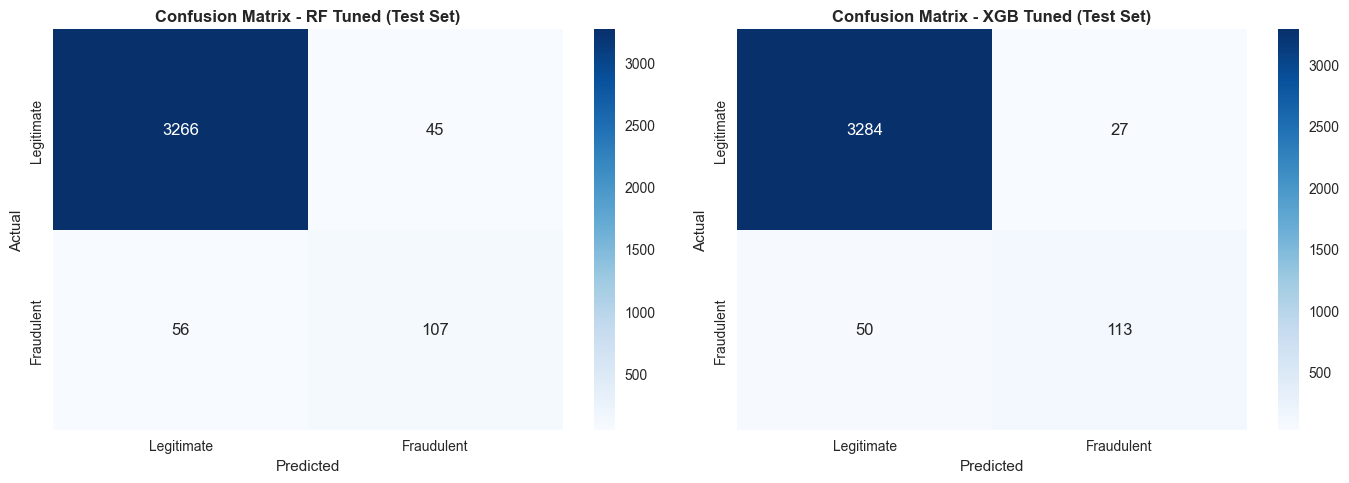

In [14]:
# Confusion Matrix
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, m, t in zip(axes, [best_rf, best_xgb], ['RF Tuned', 'XGB Tuned']):
    cm = confusion_matrix(y_test, m.predict(X_test))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['Legitimate', 'Fraudulent'],
                yticklabels=['Legitimate', 'Fraudulent'])
    ax.set_title(f'Confusion Matrix - {t} (Test Set)', fontweight='bold')
    ax.set_ylabel('Actual'); ax.set_xlabel('Predicted')
plt.tight_layout(); plt.show()

**Insight**
- Kalau kita adu kedua model ini, XGBoost (XGB Tuned) keluar sebagai pemenangnya. Model ini lebih jeli menangkap loker bodong dengan berhasil mendeteksi 113 kasus penipuan, mengalahkan Random Forest yang hanya sanggup mendeteksi 107 kasus.
- Walaupun XGBoost performanya paling bagus, kedua model ini masih punya PR. Ternyata masih ada 50 loker palsu di XGBoost (dan 56 di RF) yang berhasil lolos dan dianggap sebagai loker aman. Untuk implementasi ke depannya, angka lolos ini harus terus ditekan karena berisiko tinggi membuat pencari kerja tetap tertipu.

## Visualization & Exploratory Analysis

In [15]:
# Aggregate data
cs_eda = df.groupby('country').agg(
    total=('fraudulent', 'count'),
    fraud=('fraudulent', 'sum')
).reset_index()
cs_eda['fraud_rate'] = (cs_eda['fraud'] / cs_eda['total'] * 100).round(2)
cs_eda = cs_eda[cs_eda['total'] >= 10].sort_values('fraud_rate', ascending=False)

TKW = ['Saudi Arabia', 'Malaysia', 'Singapore', 'Hong Kong', 'Taiwan', 'UAE',
       'South Korea', 'Japan', 'Brunei', 'Kuwait', 'Qatar', 'Jordan', 'China']
tkw_stats = cs_eda[cs_eda['country'].isin(TKW)].sort_values('fraud_rate', ascending=False)

### Pertanyaan 1: Seberapa besar Fraud Rate di Negara Tujuan TKW?

     country  total  fraud  fraud_rate
    Malaysia     21     12       57.14
       Qatar     21      6       28.57
Saudi Arabia     15      1        6.67
         UAE     54      1        1.85
 South Korea     10      0        0.00
   Singapore     75      0        0.00
       China     15      0        0.00
   Hong Kong     77      0        0.00
       Japan     20      0        0.00


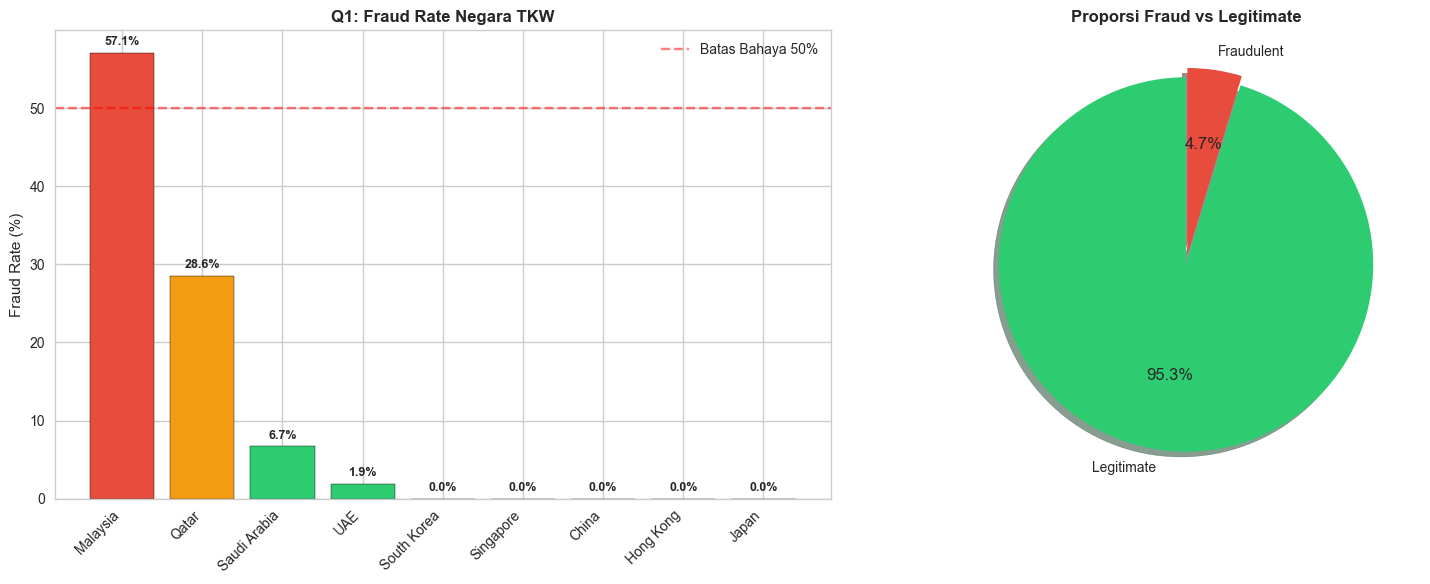

In [16]:
print(tkw_stats[['country', 'total', 'fraud', 'fraud_rate']].to_string(index=False))

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
colors_q1 = ['#e74c3c' if r > 50 else '#f39c12' if r > 25 else '#2ecc71'
             for r in tkw_stats['fraud_rate']]
axes[0].bar(tkw_stats['country'], tkw_stats['fraud_rate'],
            color=colors_q1, edgecolor='black')
axes[0].set_ylabel('Fraud Rate (%)')
axes[0].set_title('Q1: Fraud Rate Negara TKW', fontweight='bold')
axes[0].axhline(y=50, color='red', linestyle='--', alpha=0.5, label='Batas Bahaya 50%')
axes[0].legend()
plt.sca(axes[0])
plt.xticks(rotation=45, ha='right')
for i, (_, row) in enumerate(tkw_stats.iterrows()):
    axes[0].text(i, row['fraud_rate'] + 1, f"{row['fraud_rate']:.1f}%",
                 ha='center', fontsize=9, fontweight='bold')
fraud_counts = df['fraudulent'].value_counts()
axes[1].pie(fraud_counts.values, labels=['Legitimate', 'Fraudulent'],
            autopct='%1.1f%%', colors=['#2ecc71', '#e74c3c'],
            startangle=90, explode=(0, 0.05), shadow=True)
axes[1].set_title('Proporsi Fraud vs Legitimate', fontweight='bold')
plt.tight_layout(); plt.show()

**Insight**
- Dari grafik batang terlihat jelas kalau lowongan kerja dengan tujuan Malaysia punya risiko paling tinggi. Dari total 21 loker, 12 di antaranya (57,1%) adalah penipuan. Angka ini bahkan menjebol garis batas bahaya 50%.
- Qatar menyusul di posisi kedua dengan tingkat penipuan lumayan tinggi yaitu 28,6%. Sebaliknya, negara-negara tujuan Asia Timur dan Tenggara lainnya seperti Singapura, Hong Kong, Jepang, Korea Selatan, dan China bersih dari kasus penipuan (0%) di dataset ini.

### Pertanyaan 2: Berapa rata-rata perbedaan gaji antara Salary Fraud vs Legitimate? Apakah lowongan palsu menawarkan gaji lebih tinggi?

                 mean   median          std
fraudulent                                 
0           738722.82  50000.0  23619140.35
1           119224.45  40000.0    516430.92


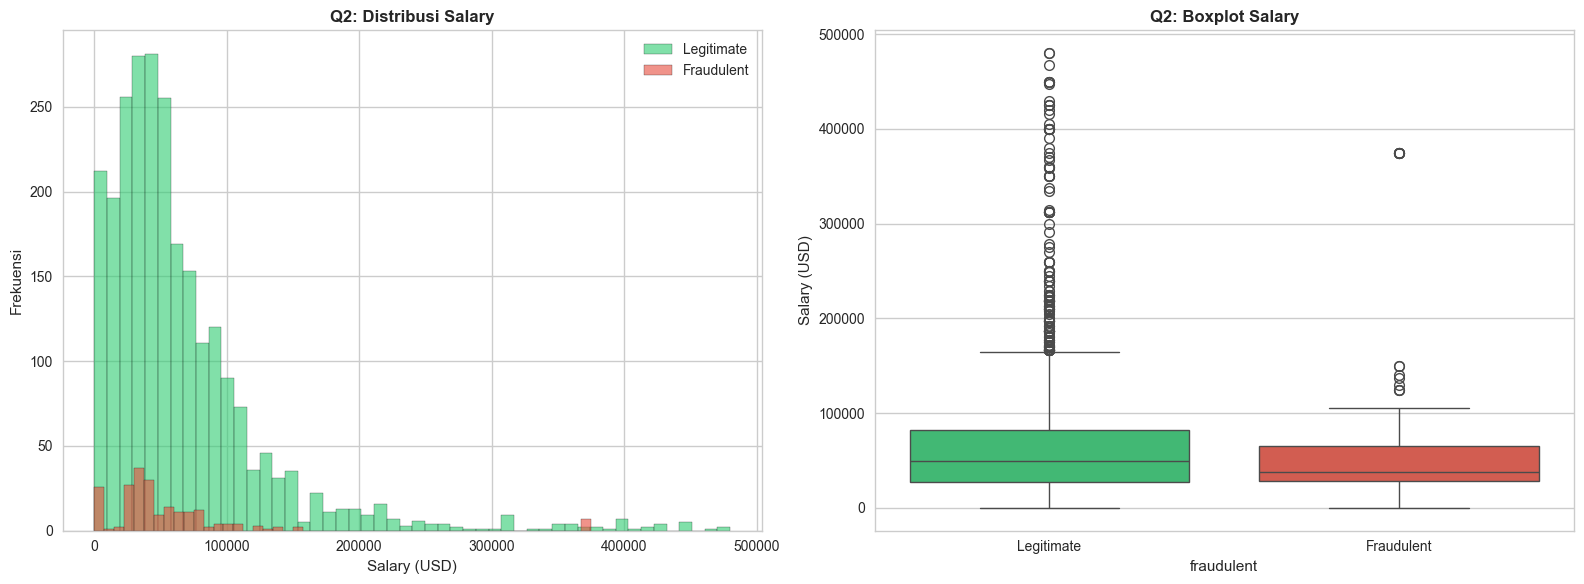

In [17]:
df_sal = df[df['salary_mid'].notna()].copy()
sal_stats = df_sal.groupby('fraudulent')['salary_mid'].agg(['mean', 'median', 'std']).round(2)
print(sal_stats)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
for label, color in [(0, '#2ecc71'), (1, '#e74c3c')]:
    sub = df_sal[(df_sal['fraudulent'] == label) & (df_sal['salary_mid'] < 500000)]['salary_mid']
    lbl = 'Legitimate' if label == 0 else 'Fraudulent'
    axes[0].hist(sub, bins=50, alpha=0.6, label=lbl, color=color, edgecolor='black')
axes[0].set_title('Q2: Distribusi Salary', fontweight='bold')
axes[0].set_xlabel('Salary (USD)'); axes[0].set_ylabel('Frekuensi'); axes[0].legend()
sns.boxplot(data=df_sal[df_sal['salary_mid'] < 500000], x='fraudulent', y='salary_mid',
            ax=axes[1], palette=['#2ecc71', '#e74c3c'])
axes[1].set_xticklabels(['Legitimate', 'Fraudulent'])
axes[1].set_title('Q2: Boxplot Salary', fontweight='bold'); axes[1].set_ylabel('Salary (USD)')
plt.tight_layout(); plt.show()

**Insight**
- Rata-rata gaji loker asli terlihat sangat bengkak (sampai 738 ribu) karena ada beberapa angka gaji yang terlalu ekstrem. Tapi kalau kita pakai nilai tengah (median) yang lebih realistis, standar gaji loker asli ada di angka 50.000, sedikit lebih tinggi dari loker palsu yang ada di angka 40.000.
- Dari grafik boxplot, sebaran gaji loker bodong (warna merah) bentuk kotaknya lebih rapat dan tidak punya banyak pencilan atas dibanding loker asli. Ini menunjukkan penipu cenderung memasang nominal gaji di angka standar biar terlihat wajar dan pelamar tidak gampang curiga.
- Lewat grafik histogram, kelihatan jelas kalau mayoritas tawaran gaji dari kedua jenis loker paling banyak berkumpul di rentang 0 sampai 100.000. Loker palsu nyaris tidak ada yang terang-terangan menuliskan angka gaji super tinggi di sistem.

### Pertanyaan 3: Fitur apa yang paling berpengaruh dalam mendeteksi lowongan palsu?

  [OK] SHAP berhasil (base_score patched -> 0.5)


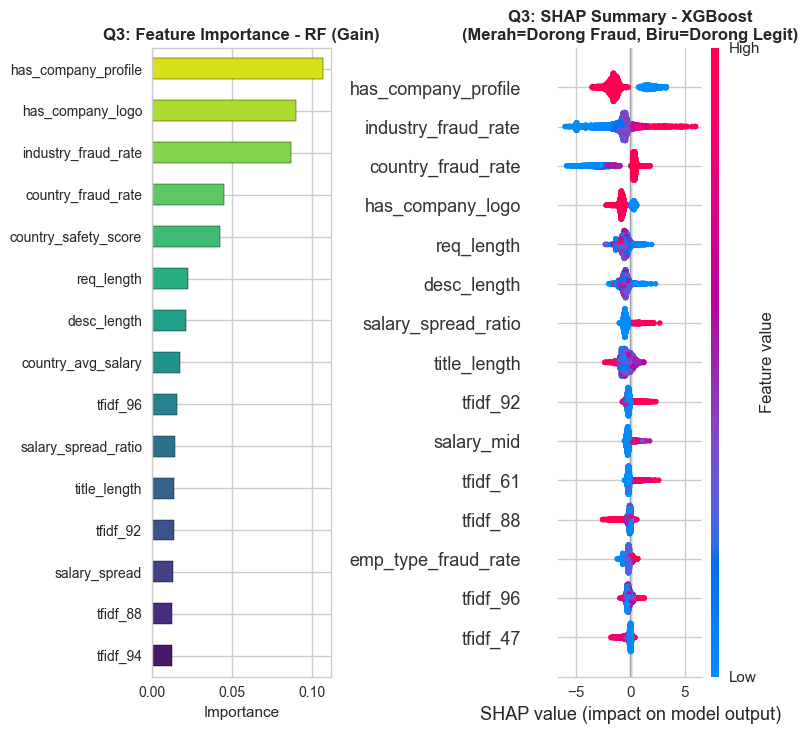

Fitur SHAP terpenting: has_company_profile


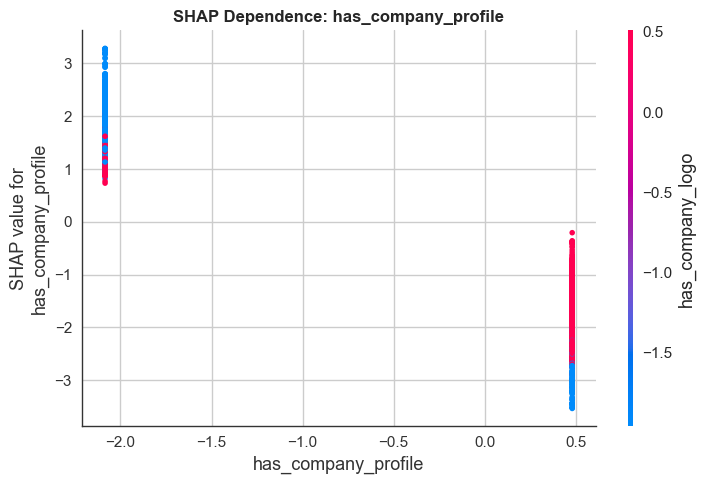

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(18, 8))
 
# Gain-based feature importance untuk RF (subplot kiri)
imp_rf = pd.Series(best_rf.feature_importances_, index=FEATURES).sort_values(ascending=True)
imp_rf.tail(15).plot(kind='barh', ax=axes[0],
                     color=sns.color_palette('viridis', 15), edgecolor='black')
axes[0].set_title('Q3: Feature Importance - RF (Gain)', fontweight='bold')
axes[0].set_xlabel('Importance')
 
def _get_shap_safe_explainer(xgb_clf):
    booster  = xgb_clf.get_booster()
    cfg_str  = booster.save_config()
    cfg_dict = _json.loads(cfg_str)
 
    raw_bs = cfg_dict['learner']['learner_model_param']['base_score']
    clean_bs = float(str(raw_bs).strip('[]'))
    booster.set_param('base_score', clean_bs)
 
    return shap.TreeExplainer(booster), clean_bs
 
plt.sca(axes[1])
shap_values   = None
use_shap      = False
try:
    explainer, bs = _get_shap_safe_explainer(best_xgb)
    shap_values   = explainer.shap_values(X_test)
    shap.summary_plot(shap_values, X_test, feature_names=FEATURES,
                      max_display=15, show=False)
    axes[1].set_title('Q3: SHAP Summary - XGBoost\n(Merah=Dorong Fraud, Biru=Dorong Legit)',
                      fontweight='bold')
    use_shap = True
    print(f"  [OK] SHAP berhasil (base_score patched -> {bs})")
except Exception as e:
    print(f"  [WARN] SHAP gagal ({e}). Fallback ke XGBoost feature gain.")
    imp_xgb = pd.Series(best_xgb.feature_importances_,
                        index=FEATURES).sort_values(ascending=True)
    imp_xgb.tail(15).plot(kind='barh', ax=axes[1],
                          color=sns.color_palette('magma', 15), edgecolor='black')
    axes[1].set_title('Q3: Feature Importance - XGBoost (Gain)\n[SHAP fallback]',
                      fontweight='bold')
    axes[1].set_xlabel('Importance')
 
plt.tight_layout(); plt.show()
 
# SHAP dependence plot untuk fitur terpenting (hanya jika SHAP berhasil)
if use_shap and shap_values is not None:
    top_shap_feat = pd.Series(
        np.abs(shap_values).mean(axis=0), index=FEATURES
    ).sort_values(ascending=False).index[0]
    print(f"Fitur SHAP terpenting: {top_shap_feat}")
    shap.dependence_plot(top_shap_feat, shap_values, X_test,
                         feature_names=FEATURES, show=False)
    plt.title(f'SHAP Dependence: {top_shap_feat}', fontweight='bold')
    plt.tight_layout(); plt.show()

**Insight**
- Fitur has_company_profile konsisten menjadi indikator paling kuat, baik di model Random Forest maupun XGBoost. Dari plot SHAP, terlihat jelas kalau profil perusahaannya kosong (titik biru), model akan langsung memberikan dorongan besar ke arah prediksi loker palsu (Fraud).
- Fitur rekayasa yang dibuat sebelumnya seperti industry_fraud_rate dan country_fraud_rate terbukti akurat dan menempati peringkat atas. Semakin tinggi riwayat rasio penipuan di suatu industri atau negara (titik merah pada plot), semakin yakin model mengklasifikasikannya sebagai penipuan.
- Model sangat mencurigai lowongan yang malas memberikan detail. Selain ketiadaan profil, absennya logo perusahaan (has_company_logo) diidentifikasi oleh XGBoost sebagai pola utama yang sering dipakai oleh loker bodong.

### Pertanyaan 4: Pola pekerjaan & tipe employment yang sering menjadi target lowongan palsu?

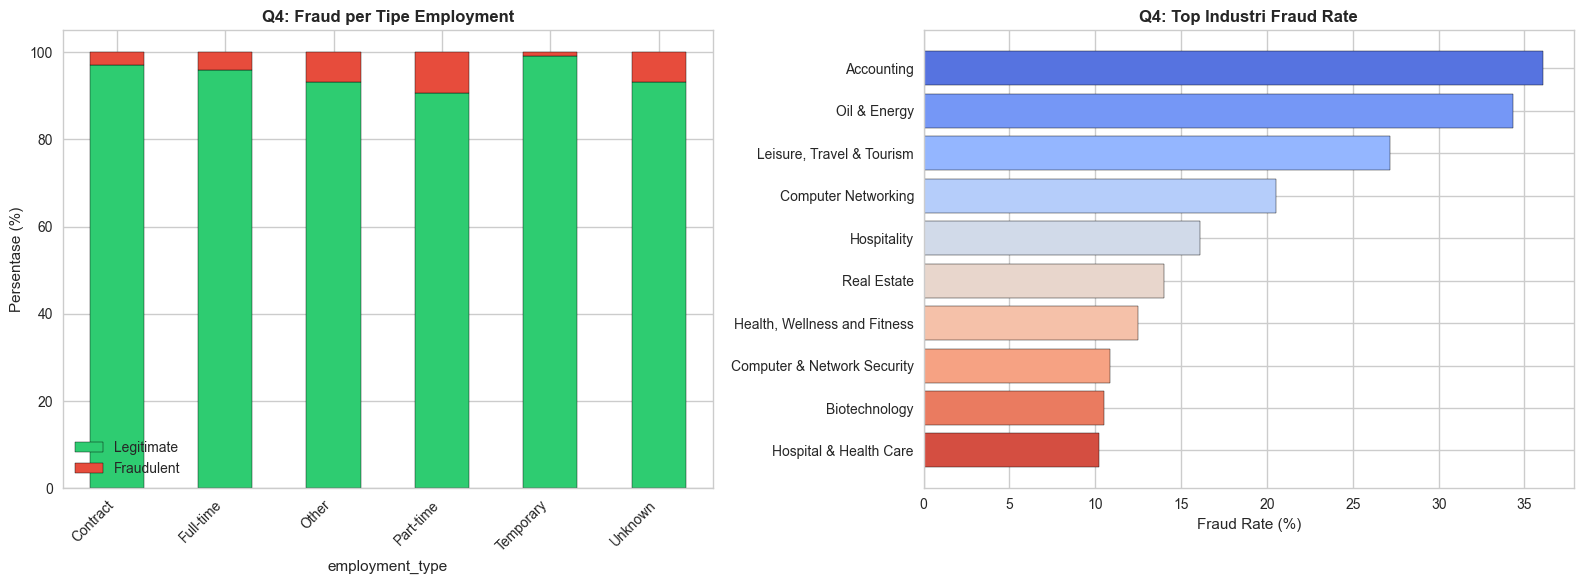

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
emp = df.groupby(['employment_type', 'fraudulent']).size().unstack(fill_value=0)
emp_pct = emp.div(emp.sum(axis=1), axis=0) * 100
emp_pct.plot(kind='bar', stacked=True, ax=axes[0],
             color=['#2ecc71', '#e74c3c'], edgecolor='black')
axes[0].set_title('Q4: Fraud per Tipe Employment', fontweight='bold')
axes[0].set_ylabel('Persentase (%)'); axes[0].legend(['Legitimate', 'Fraudulent'])
plt.sca(axes[0]); plt.xticks(rotation=45, ha='right')

ind_eda = df.groupby('industry').agg(
    total=('fraudulent', 'count'), fraud=('fraudulent', 'sum')
).reset_index()
ind_eda['fraud_rate'] = (ind_eda['fraud'] / ind_eda['total'] * 100).round(2)
ind_eda = ind_eda[ind_eda['total'] >= 20].sort_values('fraud_rate', ascending=False).head(10)
axes[1].barh(ind_eda['industry'], ind_eda['fraud_rate'],
             color=sns.color_palette('coolwarm', len(ind_eda)), edgecolor='black')
axes[1].set_xlabel('Fraud Rate (%)'); axes[1].set_title('Q4: Top Industri Fraud Rate', fontweight='bold')
axes[1].invert_yaxis()
plt.tight_layout(); plt.show()

**Insight**
- Kalau kita perhatikan proporsi warna merah di grafik sebelah kiri, penipu paling suka memasang loker dengan tipe Part-time (paruh waktu) atau yang statusnya tidak disebutkan sama sekali (Unknown / Other). Sebaliknya, lowongan Full-time atau Contract proporsi penipuannya jauh lebih kecil dan relatif lebih aman.
- Dari grafik batang di sebelah kanan, terlihat jelas kalau industri Accounting (Akuntansi) dan Oil & Energy (Minyak & Gas) menempati posisi teratas sebagai ladang penipuan. Tingkat loker bodong di dua sektor ini sangat tinggi, menembus angka di atas 30%. Sektor pariwisata (Leisure, Travel & Tourism) juga menyusul di urutan ketiga.
- Jika kedua data ini digabungkan, polanya sangat masuk akal. Penipu sering mendompleng nama industri besar yang terkesan bonafide dan bergaji tinggi (seperti energi atau akuntansi), tapi menawarkannya dalam bentuk kerja paruh waktu atau freelance agar pelamar cepat tergiur mendaftar tanpa harus melewati proses seleksi rekrutmen yang ketat.

### Pertanyaan 5: Performa model setelah tuning vs baseline?

       Model  Accuracy    F1   AUC
 RF Baseline     97.70 67.74 96.52
XGB Baseline     97.24 70.73 95.93
    RF Tuned     97.09 67.94 95.49
   XGB Tuned     97.78 74.59 96.93


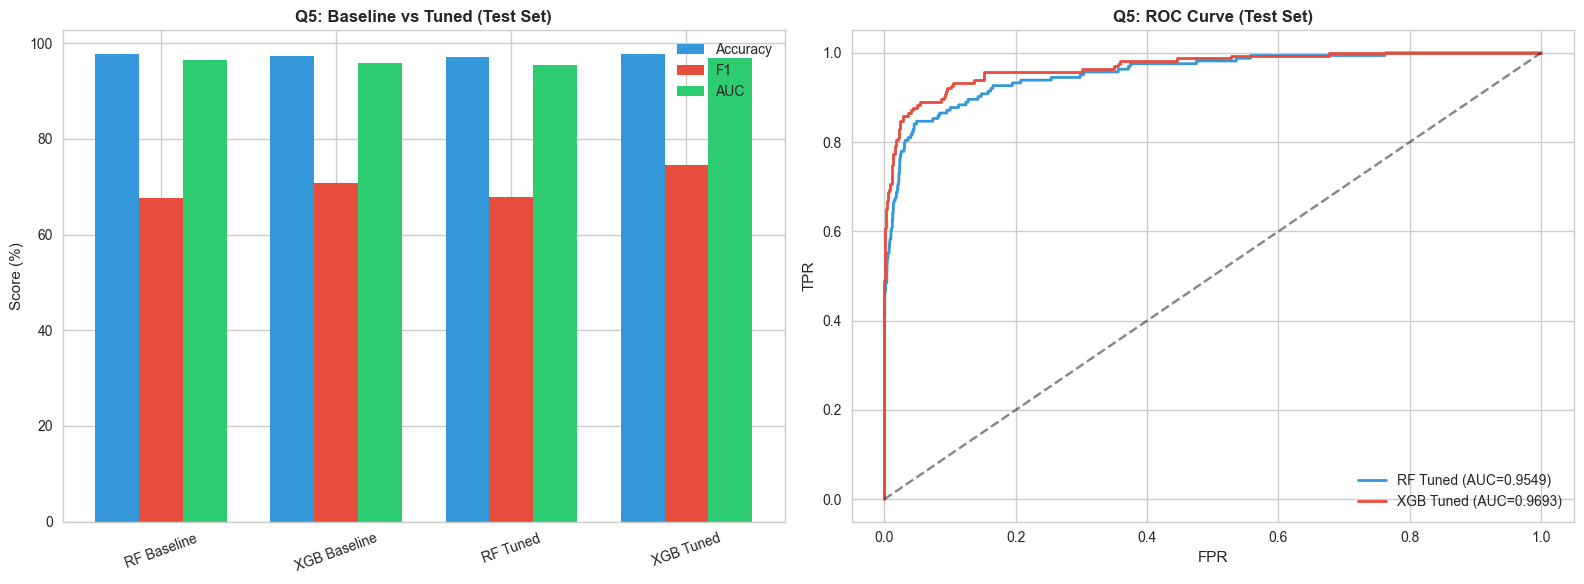

In [20]:
print(results_df.to_string(index=False))

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
x_pos = np.arange(len(results_df)); w = 0.25
axes[0].bar(x_pos - w, results_df['Accuracy'], w, label='Accuracy', color='#3498db')
axes[0].bar(x_pos,     results_df['F1'],       w, label='F1',       color='#e74c3c')
axes[0].bar(x_pos + w, results_df['AUC'],      w, label='AUC',      color='#2ecc71')
axes[0].set_xticks(x_pos)
axes[0].set_xticklabels(results_df['Model'], rotation=20)
axes[0].set_ylabel('Score (%)'); axes[0].legend()
axes[0].set_title('Q5: Baseline vs Tuned (Test Set)', fontweight='bold')

for m, name, color in [(best_rf, 'RF Tuned', '#3498db'), (best_xgb, 'XGB Tuned', '#e74c3c')]:
    fpr, tpr, _ = roc_curve(y_test, m.predict_proba(X_test)[:, 1])
    auc_val     = roc_auc_score(y_test, m.predict_proba(X_test)[:, 1])
    axes[1].plot(fpr, tpr, label=f'{name} (AUC={auc_val:.4f})', color=color, linewidth=2)
axes[1].plot([0, 1], [0, 1], 'k--', alpha=0.5)
axes[1].set_xlabel('FPR'); axes[1].set_ylabel('TPR')
axes[1].set_title('Q5: ROC Curve (Test Set)', fontweight='bold')
axes[1].legend()
plt.tight_layout(); plt.show()

**Insight**
- Proses hyperparameter tuning terbukti sangat sukses untuk XGBoost. Model XGB Tuned berhasil keluar sebagai pemenang di semua metrik evaluasi. Lonjakan performa paling berharga ada di metrik F1 Score, yang naik dari 70,73% menjadi 74,59%. Kurva ROC di sebelah kanan juga mengonfirmasi keunggulan ini, di mana garis merah (XGB) konsisten berada di atas garis biru (RF).
- Di grafik batang, semua model terlihat sempurna dengan metrik Akurasi menembus 97%. Namun, karena data kita sebelumnya terbukti sangat timpang (jumlah loker palsu sangat sedikit), angka Akurasi ini menipu. Angka F1 Score di kisaran 67-74% menunjukkan realita performa aslinya yang lebih berat. Oleh karena itu, XGB Tuned tetap diputuskan sebagai model terbaik karena terbukti paling tangguh (F1 Score tertinggi) dalam menangani ketimpangan tersebut.

Inisialisasi PyCaret setup...
Membandingkan semua model (compare_models)...


                                    Model  Accuracy     AUC  Recall   Prec.  \
xgboost         Extreme Gradient Boosting    0.9744  0.9653  0.6629  0.7618   
rf               Random Forest Classifier    0.9747  0.9707  0.6518  0.7749   
lightgbm  Light Gradient Boosting Machine    0.9730  0.9666  0.6956  0.7204   
et                 Extra Trees Classifier    0.9760  0.9726  0.5862  0.8616   
dt               Decision Tree Classifier    0.9533  0.8175  0.6675  0.5047   
gbc          Gradient Boosting Classifier    0.9463  0.9487  0.7614  0.4607   
ada                  Ada Boost Classifier    0.9266  0.9298  0.6801  0.3541   
lr                    Logistic Regression    0.8932  0.9292  0.8029  0.2791   
lda          Linear Discriminant Analysis    0.8763  0.9290  0.8336  0.2527   
ridge                    Ridge Classifier    0.8758  0.9288  0.8292  0.2512   
svm                   SVM - Linear Kernel    0.8791  0.9143  0.8007  0.2521   
nb                            Naive Bayes    0.6876 

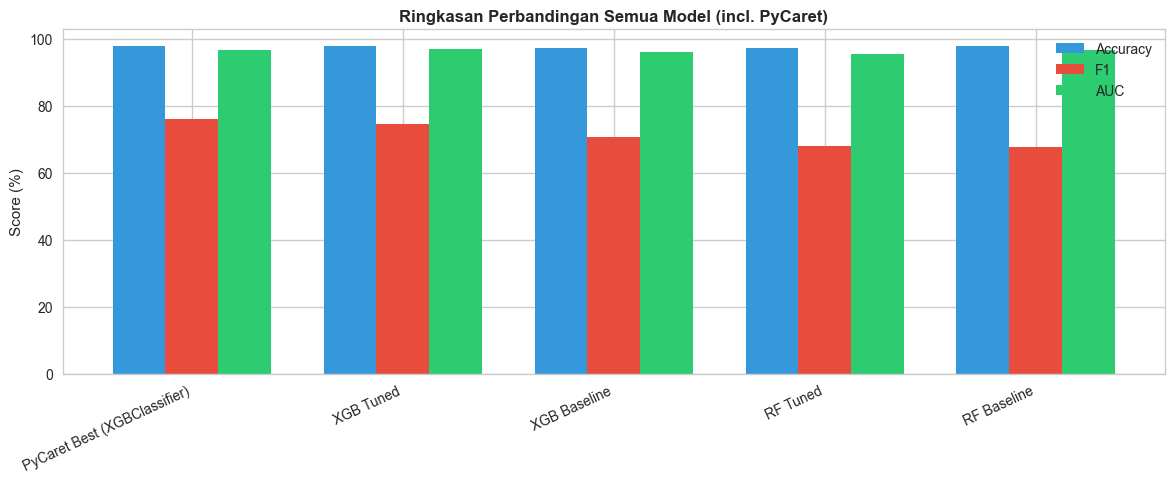

In [21]:
pycaret_df = pd.concat([X_train, y_train], axis=1) 
pycaret_df.columns = list(X_train.columns) + ['fraudulent']

print("Inisialisasi PyCaret setup...")
pc_setup(
    data         = pycaret_df,
    target       = 'fraudulent',
    fix_imbalance= True,           
    session_id   = 42,
    verbose      = False,
    html         = False,
)

print("Membandingkan semua model (compare_models)...")
pc_top_models = compare_models(sort='F1', n_select=3, verbose=True)
pc_results    = pc_pull()
print("\nHasil Compare Models (PyCaret):")
print(pc_results[['Model', 'Accuracy', 'F1', 'AUC', 'Recall', 'Prec.']].to_string())

# Model terbaik versi PyCaret
pc_best_model = pc_top_models[0] if isinstance(pc_top_models, list) else pc_top_models
print(f"\nModel terbaik PyCaret: {type(pc_best_model).__name__}")

# Visualisasi confusion matrix & AUC model terbaik PyCaret
try:
    plot_model(pc_best_model, plot='confusion_matrix', save=True)
    plot_model(pc_best_model, plot='auc',              save=True)
    print("Plot PyCaret disimpan.")
except Exception as e:
    print(f"Plot PyCaret tidak tersedia di mode non-interactive: {e}")

# Finalize model
pc_final = finalize_model(pc_best_model)

# Evaluasi PyCaret best model pada test set manual
pc_test_input = X_test.copy()
pc_test_input['fraudulent'] = y_test.values
pc_pred = predict_model(pc_final, data=pc_test_input, raw_score=True)
pc_f1   = f1_score(y_test, pc_pred['prediction_label']) * 100
pc_auc  = roc_auc_score(y_test, pc_pred['prediction_score_1']) * 100
print(f"\nPyCaret Best Model - Test Set | F1: {pc_f1:.2f}% | AUC: {pc_auc:.2f}%")

# Perbandingan semua approach
summary_rows = results.copy()
summary_rows.append({
    'Model':    f'PyCaret Best ({type(pc_best_model).__name__})',
    'Accuracy': accuracy_score(y_test, pc_pred['prediction_label']) * 100,
    'F1':       pc_f1,
    'AUC':      pc_auc,
})
summary_df = pd.DataFrame(summary_rows).round(2).sort_values('F1', ascending=False)
print(summary_df.to_string(index=False))

fig, ax = plt.subplots(figsize=(12, 5))
x     = np.arange(len(summary_df)); w = 0.25
ax.bar(x - w, summary_df['Accuracy'], w, label='Accuracy', color='#3498db')
ax.bar(x,     summary_df['F1'],       w, label='F1',       color='#e74c3c')
ax.bar(x + w, summary_df['AUC'],      w, label='AUC',      color='#2ecc71')
ax.set_xticks(x)
ax.set_xticklabels(summary_df['Model'], rotation=25, ha='right')
ax.set_ylabel('Score (%)'); ax.legend()
ax.set_title('Ringkasan Perbandingan Semua Model (incl. PyCaret)', fontweight='bold')
plt.tight_layout(); plt.show()

## Salary Prediction

In [22]:
te_sal = ce.TargetEncoder(
    cols=['required_experience', 'required_education', 'country', 'employment_type', 'industry'],
    smoothing=1.0
)

# Ambil data legitimate saja dari train set untuk melatih salary model
sal_mask_train = (
    (y_train == 0) &
    X_train_raw['salary_mid'].notna() &
    (X_train_raw['salary_mid'] > 0) &
    (X_train_raw['salary_mid'] < 500000)
)
sal_mask_test = (
    (y_test == 0) &
    X_test_raw['salary_mid'].notna() &
    (X_test_raw['salary_mid'] > 0) &
    (X_test_raw['salary_mid'] < 500000)
)

SAL_CAT_COLS = ['required_experience', 'required_education',
                'country', 'employment_type', 'industry']
SAL_NUM_COLS = ['title_length', 'desc_length', 'telecommuting']
SAL_ALL_COLS = SAL_CAT_COLS + SAL_NUM_COLS

# Hitung TargetEncoder untuk salary dari data legit train saja
sal_train_data = X_train_raw[sal_mask_train][SAL_ALL_COLS].copy()
sal_test_data  = X_test_raw[sal_mask_test][SAL_ALL_COLS].copy()
ys_tr = X_train_raw.loc[sal_mask_train, 'salary_mid']
ys_te = X_test_raw.loc[sal_mask_test, 'salary_mid']

te_sal.fit(sal_train_data[SAL_CAT_COLS], ys_tr)
sal_train_enc = te_sal.transform(sal_train_data[SAL_CAT_COLS])
sal_test_enc  = te_sal.transform(sal_test_data[SAL_CAT_COLS])

Xs_tr_enc = pd.concat([sal_train_enc, sal_train_data[SAL_NUM_COLS]], axis=1).fillna(0)
Xs_te_enc = pd.concat([sal_test_enc,  sal_test_data[SAL_NUM_COLS]], axis=1).fillna(0)

rf_reg  = RandomForestRegressor(n_estimators=200, max_depth=15, random_state=42, n_jobs=-1)
xgb_reg = XGBRegressor(n_estimators=200, max_depth=6, learning_rate=0.1, random_state=42)
rf_reg.fit(Xs_tr_enc, ys_tr)
xgb_reg.fit(Xs_tr_enc, ys_tr)

r2_rf  = r2_score(ys_te, rf_reg.predict(Xs_te_enc))
r2_xgb = r2_score(ys_te, xgb_reg.predict(Xs_te_enc))
mae_rf  = mean_absolute_error(ys_te, rf_reg.predict(Xs_te_enc))
mae_xgb = mean_absolute_error(ys_te, xgb_reg.predict(Xs_te_enc))

print(f"RF  - MAE: ${mae_rf:,.0f} | R2: {r2_rf*100:.2f}%")
print(f"XGB - MAE: ${mae_xgb:,.0f} | R2: {r2_xgb*100:.2f}%")

best_sal  = rf_reg if r2_rf >= r2_xgb else xgb_reg
sal_name  = "RF" if r2_rf >= r2_xgb else "XGB"
print(f"Model salary terpilih: {sal_name}")

RF  - MAE: $30,604 | R2: 34.23%
XGB - MAE: $31,712 | R2: 29.91%
Model salary terpilih: RF


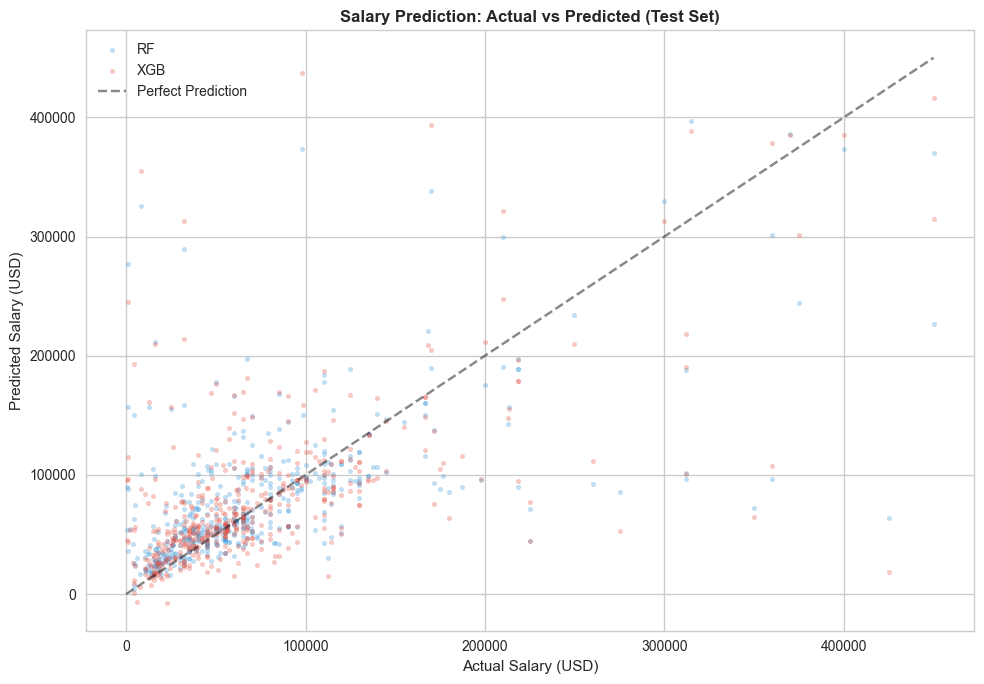

In [23]:
fig, ax = plt.subplots(figsize=(10, 7))
ax.scatter(ys_te, rf_reg.predict(Xs_te_enc),  alpha=0.3, s=10, color='#3498db', label='RF')
ax.scatter(ys_te, xgb_reg.predict(Xs_te_enc), alpha=0.3, s=10, color='#e74c3c', label='XGB')
ax.plot([0, ys_te.max()], [0, ys_te.max()], 'k--', alpha=0.5, label='Perfect Prediction')
ax.set_xlabel('Actual Salary (USD)')
ax.set_ylabel('Predicted Salary (USD)')
ax.set_title('Salary Prediction: Actual vs Predicted (Test Set)', fontweight='bold')
ax.legend(); plt.tight_layout(); plt.show()

# Tambahkan expected salary ke df
df_sal_input = df[SAL_ALL_COLS].copy()
df_sal_enc   = te_sal.transform(df_sal_input[SAL_CAT_COLS])
df_sal_full  = pd.concat([df_sal_enc, df_sal_input[SAL_NUM_COLS].reset_index(drop=True)], axis=1).fillna(0)

df['expected_salary']     = best_sal.predict(df_sal_full)
df['salary_deviation']    = np.where(
    df['expected_salary'] > 0,
    (df['salary_mid'] - df['expected_salary']) / df['expected_salary'],
    0
)
df['salary_is_fair'] = (df['salary_deviation'].abs() <= 0.3).astype(int)

**Insight**
- Dari perbandingan metrik, Random Forest (titik biru) sedikit lebih unggul daripada XGBoost dengan nilai R2 34,23% dan rata-rata meleset (MAE) sekitar 30 ribu dolar. Oleh karena itu, RF pantas dipilih sebagai model penaksir gaji.
- Kelemahan utama model ini sangat terlihat saat menemui data gaji di atas 150 ribu dolar. Titik-titiknya menyebar ke mana-mana dan menjauh dari garis ideal. Ini membuktikan bahwa model kebingungan dan sering kali menebak terlalu rendah untuk lowongan yang aslinya bergaji sangat tinggi.
- Kalau melihat grafik sebarannya, model masih cukup bagus dalam menebak gaji menengah ke bawah. Titik-titik biru dan merah terlihat menumpuk cukup rapat di sekitar garis putus-putus (garis tebakan sempurna) pada rentang gaji 0 sampai 100 ribu dolar.

## Croos-Validation Comparison

  Fold  1 | RF F1=0.6289 | XGB F1=0.7248
  Fold  2 | RF F1=0.7226 | XGB F1=0.8026
  Fold  3 | RF F1=0.6829 | XGB F1=0.7871
  Fold  4 | RF F1=0.7355 | XGB F1=0.8027
  Fold  5 | RF F1=0.6709 | XGB F1=0.7703
  Fold  6 | RF F1=0.6575 | XGB F1=0.7639
  Fold  7 | RF F1=0.7453 | XGB F1=0.7838
  Fold  8 | RF F1=0.7066 | XGB F1=0.7403
  Fold  9 | RF F1=0.6065 | XGB F1=0.6712
  Fold 10 | RF F1=0.7200 | XGB F1=0.7733

RF  Mean F1: 0.6877 (+/- 0.0442)
XGB Mean F1: 0.7620 (+/- 0.0383)

t-statistic: -8.7033
p-value:     0.000011
Cohen's d:   -2.9011  (|d|>0.5=sedang, |d|>0.8=besar)
KESIMPULAN: Perbedaan SIGNIFIKAN secara statistik (p<0.05). Model terbaik: XGBoost


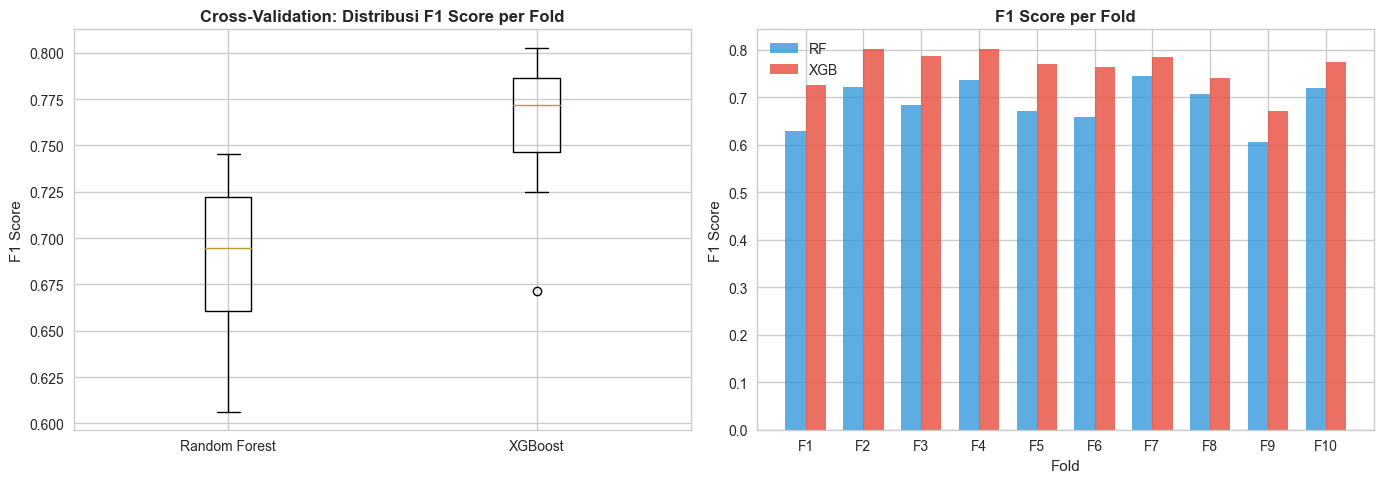

In [24]:
# Nama diubah dari A/B Testing menjadi Cross-Validation Comparison
skf = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)
rf_scores  = []
xgb_scores = []

X_full_base = df.drop(columns=['fraudulent'])
y_full      = df['fraudulent']

for fold_i, (train_idx, test_idx) in enumerate(skf.split(X_full_base, y_full)):
    X_tr_fold = X_full_base.iloc[train_idx]
    y_tr_fold = y_full.iloc[train_idx]
    X_te_fold = X_full_base.iloc[test_idx]
    y_te_fold = y_full.iloc[test_idx]

    # Feature engineering leakage-free per fold
    X_tr_unscaled, _, _, _ = create_features(X_tr_fold, X_tr_fold, y_tr_fold)
    X_te_unscaled, _, _, _ = create_features(X_te_fold, X_tr_fold, y_tr_fold)

    scaler_cv  = StandardScaler()
    X_tr_clean = pd.DataFrame(
        scaler_cv.fit_transform(X_tr_unscaled),
        columns=X_tr_unscaled.columns, index=X_tr_unscaled.index
    )
    X_te_clean = pd.DataFrame(
        scaler_cv.transform(X_te_unscaled),
        columns=X_te_unscaled.columns, index=X_te_unscaled.index
    )

    best_rf.fit(X_tr_clean, y_tr_fold)
    rf_scores.append(f1_score(y_te_fold, best_rf.predict(X_te_clean)))

    best_xgb.fit(X_tr_clean, y_tr_fold)
    xgb_scores.append(f1_score(y_te_fold, best_xgb.predict(X_te_clean)))

    print(f"  Fold {fold_i+1:2d} | RF F1={rf_scores[-1]:.4f} | XGB F1={xgb_scores[-1]:.4f}")

# Refit pada full train set setelah selesai CV
best_rf.fit(X_train, y_train)
best_xgb.fit(X_train, y_train)

rf_scores  = np.array(rf_scores)
xgb_scores = np.array(xgb_scores)

print(f"\nRF  Mean F1: {rf_scores.mean():.4f} (+/- {rf_scores.std():.4f})")
print(f"XGB Mean F1: {xgb_scores.mean():.4f} (+/- {xgb_scores.std():.4f})")

# Paired t-test + Cohen's d untuk effect size
t_stat, p_val = stats.ttest_rel(rf_scores, xgb_scores)
diff          = rf_scores - xgb_scores
cohens_d      = diff.mean() / diff.std() if diff.std() > 0 else 0

print(f"\nt-statistic: {t_stat:.4f}")
print(f"p-value:     {p_val:.6f}")
print(f"Cohen's d:   {cohens_d:.4f}  (|d|>0.5=sedang, |d|>0.8=besar)")

if p_val < 0.05:
    winner = "RF" if rf_scores.mean() > xgb_scores.mean() else "XGBoost"
    print(f"KESIMPULAN: Perbedaan SIGNIFIKAN secara statistik (p<0.05). Model terbaik: {winner}")
else:
    print("KESIMPULAN: TIDAK ada perbedaan signifikan (p>=0.05). Kedua model sebanding.")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].boxplot([rf_scores, xgb_scores], labels=['Random Forest', 'XGBoost'])
axes[0].set_ylabel('F1 Score')
axes[0].set_title('Cross-Validation: Distribusi F1 Score per Fold', fontweight='bold')

x_cv = np.arange(10); w_cv = 0.35
axes[1].bar(x_cv - w_cv/2, rf_scores,  w_cv, label='RF',  color='#3498db', alpha=0.8)
axes[1].bar(x_cv + w_cv/2, xgb_scores, w_cv, label='XGB', color='#e74c3c', alpha=0.8)
axes[1].set_xlabel('Fold'); axes[1].set_ylabel('F1 Score')
axes[1].set_title('F1 Score per Fold', fontweight='bold')
axes[1].legend()
axes[1].set_xticks(x_cv)
axes[1].set_xticklabels([f'F{i+1}' for i in range(10)])
plt.tight_layout(); plt.show()

**Insight**
- Dari 10 kali pengujian dengan potongan data yang terus diacak (Fold 1 sampai 10), grafik batang menunjukkan XGBoost (merah) tidak pernah sekalipun kalah dari Random Forest (biru). Rata-rata skor F1 XGBoost terbukti mantap di angka 76,2%, jauh meninggalkan RF yang hanya 68,7%.
- Nilai p-value yang sangat kecil (0.000011) memastikan bahwa keunggulan XGBoost ini valid secara statistik. Artinya, model XGBoost memang lebih tajam dalam mengenali pola loker bodong, bukan sekadar hoki karena kebetulan mendapat jatah pembagian data yang mudah.
- Nilai efek Cohen's d menyentuh angka 2,9. Angka ini masuk dalam kategori perbedaan yang "besar", membuktikan bahwa transisi dari Random Forest ke XGBoost benar-benar memberikan dampak perbaikan performa yang masif dan sangat signifikan untuk sistem deteksi ini.

## Save Data & Export Model

In [25]:
# Pilih final classifier berdasarkan F1 pada test set
f1_rf  = f1_score(y_test, best_rf.predict(X_test))
f1_xgb = f1_score(y_test, best_xgb.predict(X_test))
final_clf = best_xgb if f1_xgb >= f1_rf else best_rf
print(f"Final classifier dipilih: {'XGBoost' if f1_xgb >= f1_rf else 'RF'} "
      f"(XGB F1={f1_xgb:.4f}, RF F1={f1_rf:.4f})")

# Terapkan feature engineering ke seluruh df
X_full_unscaled, _, _, _ = create_features(
    df.drop(columns=['fraudulent']), X_train_raw, y_train
)
X_full_clean = pd.DataFrame(
    scaler.transform(X_full_unscaled),
    columns=X_full_unscaled.columns,
    index=X_full_unscaled.index
)

# Memastikan semua kolom FEATURES ada
for col in FEATURES:
    if col not in X_full_clean.columns:
        X_full_clean[col] = 0
X_full_clean = X_full_clean[FEATURES]

df['fraud_prediction']  = final_clf.predict(X_full_clean)
df['fraud_probability'] = final_clf.predict_proba(X_full_clean)[:, 1]

df['expected_salary_min'] = (df['expected_salary'] * 0.85).round(2)
df['expected_salary_max'] = (df['expected_salary'] * 1.15).round(2)

# Salin fitur yang sudah di-scale ke df
for col in FEATURES:
    df[col] = X_full_clean[col]

def risk_level(r):
    score = 0
    if r['fraud_probability'] > 0.7:   score += 3
    elif r['fraud_probability'] > 0.4: score += 2
    else:                               score += 1
    if r['country_safety_score'] < 0.5:   score += 2
    elif r['country_safety_score'] < 0.7: score += 1
    if r['salary_is_fair'] == 0:           score += 1
    if score >= 5:   return 'SANGAT BERBAHAYA'
    elif score >= 3: return 'BERBAHAYA'
    elif score >= 2: return 'WASPADA'
    return 'AMAN'

df['risk_level'] = df.apply(risk_level, axis=1)

# Save CSV
out_cols = [
    'title', 'location', 'country', 'salary_range',
    'salary_min', 'salary_max', 'salary_mid',
    'description', 'requirements', 'company_profile',
    'employment_type', 'industry', 'benefits',
    'required_experience', 'required_education',
    'fraudulent',
    'salary_spread', 'salary_spread_ratio', 'has_salary',
    'title_length', 'desc_length', 'req_length', 'has_company_profile',
    'scam_keyword_score', 'has_email_in_desc', 'is_free_email',
    'exclamation_count', 'is_indonesian_posting',
    'country_avg_salary', 'salary_vs_country_avg',
    'country_fraud_rate', 'country_safety_score',
    'telecommuting', 'has_company_logo', 'has_questions',
    'expected_salary', 'expected_salary_min', 'expected_salary_max',
    'salary_deviation', 'salary_is_fair',
    'fraud_prediction', 'fraud_probability', 'risk_level',
]

os.makedirs(os.path.join(os.getcwd(), 'dashboard'), exist_ok=True)
out_path = os.path.join(os.getcwd(), 'dashboard', 'main_data.csv')
df[out_cols].to_csv(out_path, index=False)
print(f"Saved: {out_path} ({len(df)} baris, {len(out_cols)} kolom)")
print(f"Risk Level: {df['risk_level'].value_counts().to_dict()}")

# Export Models
model_dir = os.path.join(os.getcwd(), 'model')
os.makedirs(model_dir, exist_ok=True)

joblib.dump(final_clf,      os.path.join(model_dir, 'fraud_detector.joblib'))
joblib.dump(best_sal,       os.path.join(model_dir, 'salary_predictor.joblib'))
joblib.dump(te_train,       os.path.join(model_dir, 'target_encoder_fraud.joblib'))
joblib.dump(te_sal,         os.path.join(model_dir, 'target_encoder_salary.joblib'))
joblib.dump(cs_avg_train,   os.path.join(model_dir, 'country_salary_avg.joblib'))
joblib.dump(tfidf_train,    os.path.join(model_dir, 'tfidf_vectorizer.joblib'))
joblib.dump(scaler,         os.path.join(model_dir, 'standard_scaler.joblib'))
joblib.dump(FEATURES,       os.path.join(model_dir, 'fraud_feature_cols.joblib'))
joblib.dump(SAL_ALL_COLS,   os.path.join(model_dir, 'salary_feature_cols.joblib'))
joblib.dump(pc_final,       os.path.join(model_dir, 'pycaret_best_model.joblib'))

print(f"\nModel disimpan di: {model_dir}")
for f in sorted(os.listdir(model_dir)):
    size = os.path.getsize(os.path.join(model_dir, f)) / 1024
    print(f"  - {f} ({size:.1f} KB)")
clear_output(wait=True)

Final classifier dipilih: XGBoost (XGB F1=0.7459, RF F1=0.6794)
Saved: g:\CODING\Team-DS\dashboard\main_data.csv (17368 baris, 43 kolom)
Risk Level: {'BERBAHAYA': 11211, 'WASPADA': 4642, 'SANGAT BERBAHAYA': 775, 'AMAN': 740}

Model disimpan di: g:\CODING\Team-DS\model
  - country_salary_avg.joblib (1.0 KB)
  - fraud_detector.joblib (795.8 KB)
  - fraud_feature_cols.joblib (1.5 KB)
  - pycaret_best_model.joblib (555.7 KB)
  - salary_feature_cols.joblib (0.1 KB)
  - salary_predictor.joblib (17482.1 KB)
  - standard_scaler.joblib (5.7 KB)
  - target_encoder_fraud.joblib (22.2 KB)
  - target_encoder_salary.joblib (21.9 KB)
  - tfidf_vectorizer.joblib (11076.7 KB)


In [26]:
print("=== SIMULASI PREDIKSI LOKER BARU (INFERENCE) ===\n")

skenario_baru = [
    {
        'scenario': 'Loker Bodong (Malaysia)',
        'has_company_profile': 0,
        'has_company_logo': 0,
        'country_fraud_rate': 0.57,
        'industry_fraud_rate': 0.35,
        'scam_keyword_score': 6,
        'desc_length': 300,
        'salary_spread_ratio': 0.1
    },
    {
        'scenario': 'Loker Aman (Singapore)',
        'has_company_profile': 1,
        'has_company_logo': 1,
        'country_fraud_rate': 0.00,
        'industry_fraud_rate': 0.02,
        'scam_keyword_score': 0,
        'desc_length': 1200,
        'salary_spread_ratio': 0.2
    },
    {
        'scenario': 'Loker Abu-abu (Qatar)',
        'has_company_profile': 1,
        'has_company_logo': 0,
        'country_fraud_rate': 0.28,
        'industry_fraud_rate': 0.20,
        'scam_keyword_score': 2,
        'desc_length': 600,
        'salary_spread_ratio': 0.0
    }
]

inference_df = pd.DataFrame(skenario_baru)
scenario_names = inference_df['scenario'].tolist()
inference_features = inference_df.drop(columns=['scenario'])

inference_features = inference_features.reindex(columns=X_train.columns, fill_value=0)

rf_preds  = best_rf.predict(inference_features)
rf_probs  = best_rf.predict_proba(inference_features)[:, 1]

xgb_preds = best_xgb.predict(inference_features)
xgb_probs = best_xgb.predict_proba(inference_features)[:, 1]

results = []
for i in range(len(scenario_names)):
    results.append({
        'Skenario (Negara)': scenario_names[i],
        'Prediksi RF': '🚨 FRAUD' if rf_preds[i] == 1 else '✅ LEGIT',
        'Probabilitas RF': f"{rf_probs[i]*100:.1f}%",
        'Prediksi XGB': '🚨 FRAUD' if xgb_preds[i] == 1 else '✅ LEGIT',
        'Probabilitas XGB': f"{xgb_probs[i]*100:.1f}%",
    })

inference_result_df = pd.DataFrame(results)
print(inference_result_df.to_string(index=False))

=== SIMULASI PREDIKSI LOKER BARU (INFERENCE) ===

      Skenario (Negara) Prediksi RF Probabilitas RF Prediksi XGB Probabilitas XGB
Loker Bodong (Malaysia)     ✅ LEGIT           13.5%      ✅ LEGIT            13.2%
 Loker Aman (Singapore)     ✅ LEGIT            6.7%      ✅ LEGIT             0.0%
  Loker Abu-abu (Qatar)     ✅ LEGIT            8.7%      ✅ LEGIT             0.0%
